# 1.4 サポートベクターマシン（2/2）実践のコツ・カーネル・数式

**原典**: scikit-learn User Guide [1.4. Support Vector Machines](https://scikit-learn.org/stable/modules/svm.html) の 1.4.4〜1.4.8（v1.9.1）

| | |
|---|---|
| **このノートで分かるようになること** | ・SVM の計算量と、`SVC` / `LinearSVC` の使い分けが分かる<br>・特徴のスケーリング、`C`、`nu`、`class_weight` など、実践のコツを実験で確かめる<br>・4 つのカーネルと、RBF カーネルの `C` と `gamma` の役割を、学習した境界の図で説明できる<br>・SVM の主問題・双対問題の数式を読み、`dual_coef_` などの属性と対応づけられる |
| **前提** | [1/2 分類と回帰](./04_svm_1_classification_regression.ipynb)、[1.3 カーネルリッジ回帰](./03_kernel_ridge.ipynb)（カーネル、双対） |
| **目安時間** | 90〜120 分 |

記号の意味は 1/2 と同じです（📖 ガイドの解説 / 💡 補足 / 📚 用語 / 🔢 数式を読む / 🎯 なぜ使うのか / 🏭 利用例 / 🕰️ 歴史 / 🧪 やってみよう / 📈 学習したモデルを見る / 👀 結果の読み方 / ⚠️ つまずきポイント）。

> ⚠️ このノートには**実行時間を測る**実験があります。時間の値は、実行するコンピュータによって変わります。

### 目次

1. 1.4.4 計算量
2. 1.4.5 実践のコツ
3. 1.4.6 カーネル関数（RBF カーネルのパラメータ / 独自のカーネル）
4. 1.4.7 数式（SVC / LinearSVC / NuSVC / SVR / LinearSVR）
5. 1.4.8 実装の詳細
6. まとめ・確認クイズ

## セットアップ

実行済みの出力つきで保存しています。手元で動かす場合は、上から順に実行してください。

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib  # グラフで日本語を表示するため

from sklearn import linear_model as lm

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
plt.rcParams.update({"figure.figsize": (6, 3.6), "figure.dpi": 80, "axes.grid": True})
rng = np.random.RandomState(0)  # 乱数の種を固定（同じ結果を再現するため）

import time
from sklearn import svm
from sklearn.datasets import make_blobs, make_moons, make_circles, make_classification, load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel

def plot_svc(ax, model, X, y, title, margins=True, show_sv=True):
    # 決定関数の等高線: 実線 = 決定境界（0）、点線 = マージンの境界（±1）、丸印 = サポートベクター
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 250),
                         np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 250))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap="RdBu_r", alpha=0.25)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1] if margins else [0], colors="k",
               linestyles=["--", "-", "--"] if margins else ["-"], linewidths=[1, 2, 1] if margins else [2])
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu_r", edgecolor="k", s=18, zorder=2)
    if show_sv and hasattr(model, "support_vectors_") and len(model.support_vectors_):
        sv = model.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=90, facecolors="none", edgecolors="k", linewidths=1, zorder=3)
    ax.set_title(title, fontsize=9); ax.grid(False)

def best_time(func, repeat=3):
    times = []
    for _ in range(repeat):
        t = time.perf_counter(); func(); times.append(time.perf_counter() - t)
    return min(times)

---
## 1. 計算量（1.4.4 Complexity）

### 📖 ガイドの解説

SVM は強力な道具ですが、計算とメモリの必要量は、学習データの数とともに急速に増えます。SVM の中心は、サポートベクターを学習データの残りから分ける**二次計画問題（QP）**です。libsvm ベースの実装が使う QP ソルバの計算量は、libsvm のキャッシュが実際にどれだけ効率よく使われるか（データ次第）によって、$O(n_{features} \times n_{samples}^2)$ から $O(n_{features} \times n_{samples}^3)$ の間になります。データが非常に疎なら、$n_{features}$ は「1 サンプルあたりの 0 でない特徴の数の平均」に置き換えます。

線形の場合、`LinearSVC` が使う liblinear の実装は、libsvm ベースの `SVC` よりずっと効率的で、数百万のサンプルや特徴に対しても、ほぼ線形にスケールします。

> 📚 **用語**
> - **二次計画問題（QP, Quadratic Programming）**: 二次式の目的関数を、一次式の制約のもとで最小化する最適化問題。SVM の学習はこの形になる（4 章の数式）。
> - **キャッシュ**: 一度計算したカーネルの値を、メモリに取っておいて使い回す仕組み。同じ値を何度も計算しなくて済む。

### 🔢 数式を読む

| 計算量 | データが 10 倍になると、学習時間は | 意味 |
|---|---|---|
| $O(n_{features} \times n_{samples}^2)$ | 約 100 倍 | キャッシュがよく効く場合 |
| $O(n_{features} \times n_{samples}^3)$ | 約 1000 倍 | キャッシュが効かない場合 |
| ほぼ線形（`LinearSVC`） | 約 10 倍 | liblinear |

**日本語で読むと**: カーネル SVM の学習時間は、サンプル数の 2 乗〜3 乗で増える。数万件を超えると現実的でなくなることが多いので、線形で足りるなら `LinearSVC` を使う。

### 🧪 やってみよう / 📈: サンプル数による学習時間の増え方

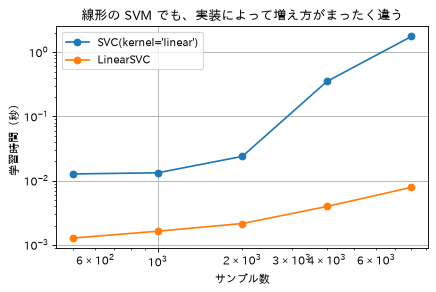

,SVC(kernel='linear'),LinearSVC,倍率（SVC / LinearSVC）
サンプル数,,,
500,0.0127,0.0013,9.9623
1000,0.0133,0.0016,8.1295
2000,0.0239,0.0022,11.1070
4000,0.3506,0.0040,88.4952
8000,1.7618,0.0079,223.9368


In [2]:
records = []
for n in [500, 1000, 2000, 4000, 8000]:
    Xc, yc = make_classification(n_samples=n, n_features=20, random_state=0)
    records.append({"サンプル数": n,
                    "SVC(kernel='linear')": best_time(lambda: svm.SVC(kernel="linear").fit(Xc, yc), repeat=1),
                    "LinearSVC": best_time(lambda: svm.LinearSVC().fit(Xc, yc))})
df_c = pd.DataFrame(records).set_index("サンプル数")
df_c.plot(loglog=True, marker="o"); plt.ylabel("学習時間（秒）")
plt.title("線形の SVM でも、実装によって増え方がまったく違う"); plt.show()
df_c["倍率（SVC / LinearSVC）"] = df_c["SVC(kernel='linear')"] / df_c["LinearSVC"]
df_c

### 👀 結果の読み方（両対数グラフ: 傾きが急なほど、データの増加に弱い）

- `SVC(kernel='linear')`（libsvm）は、サンプルが 2 倍になるたびに学習時間が数倍に増え、傾きが急です。
- `LinearSVC`（liblinear）は、ほぼ一定の緩やかな傾きで、サンプル数が増えても速いままです。
- 同じ「線形の SVM」でも、サンプルが数千になると時間の差は数十〜数百倍に開きます（表の右端の列）。**線形カーネルで十分なら、`SVC(kernel='linear')` ではなく `LinearSVC` を使う**のが実践的です。

---
## 2. 実践のコツ（1.4.5 Tips on Practical Use）

### 📖 ガイドの解説（9 つのコツ）

**① データのコピーを避ける**: `SVC`、`SVR`、`NuSVC`、`NuSVR` では、特定のメソッドに渡すデータが **C 順序で連続した倍精度**でないと、内部の C 実装を呼ぶ前にコピーされます。NumPy の配列が C 順序で連続しているかは、`flags` 属性で確かめられます。`LinearSVC`（と `LogisticRegression`）では、NumPy の配列はどれも、liblinear 内部の疎なデータ表現（倍精度の浮動小数点数と、0 でない要素の int32 の番号）にコピー・変換されます。密な C 順序・倍精度の配列をコピーせずに大規模な線形分類器を学習したいなら、`SGDClassifier` を使うことが勧められています。目的関数は、`LinearSVC` とほぼ同じになるように設定できます。

**② カーネルのキャッシュの大きさ**: `SVC`、`SVR`、`NuSVC`、`NuSVR` では、カーネルのキャッシュの大きさが、大きな問題での実行時間に強く影響します。RAM に余裕があれば、`cache_size` を既定の 200（MB）より大きく、たとえば 500（MB）や 1000（MB）にすることが勧められています。

**③ `C` の設定**: `C` は既定で 1 で、妥当な既定値です。ノイズの多い観測がたくさんあるなら、`C` を**小さく**します。`C` を小さくすることは、正則化を強くすることに当たります。`LinearSVC` と `LinearSVR` は、`C` が大きくなると `C` にあまり敏感でなくなり、ある値を超えると予測結果は改善しなくなります。一方、`C` が大きいほど学習に時間がかかり、最大で 10 倍ほど長くなることがあります（Fan ら, 2008）。

**④ スケーリング**: SVM のアルゴリズムは**スケール不変ではない**ので、データのスケーリングを強く勧めます。たとえば、入力ベクトル `X` の各属性を [0, 1] や [−1, +1] にスケーリングするか、平均 0・分散 1 に標準化します。**テストのベクトルにも同じスケーリングを適用**しないと、意味のある結果になりません。これは `Pipeline` を使えば簡単にできます。

**⑤ `shrinking` 引数**: libsvm の論文から引用すると、「反復回数が多い場合、shrinking は学習時間を短くできる。しかし、最適化問題を緩く解く（たとえば停止の許容誤差を大きくする）場合は、shrinking を使わないほうがずっと速いことがある」。

**⑥ `nu` 引数**: `NuSVC` / `OneClassSVM` / `NuSVR` の `nu` は、学習データの誤差とサポートベクターの**割合**を近似します。

**⑦ 不均衡なデータ**: `SVC` でデータが不均衡なら（たとえば正例が多く負例が少ない）、`class_weight='balanced'` にするか、別の罰則パラメータ `C` を試します。

**⑧ 実装の中の乱数**: `SVC` と `NuSVC` の内部実装が乱数を使うのは、確率推定のときにデータをシャッフルするためだけです（`probability=True` のとき）。この乱数は `random_state` で制御できます。`probability=False` なら乱数を使わないので、`random_state` は結果に影響しません。`OneClassSVM` も同様で、確率推定がないので乱数を使いません。`LinearSVC` の内部実装は、双対座標降下法（`dual=True`）で学習するときに、特徴の選択に乱数を使います。そのため、同じ入力データでも結果が少し違うことは珍しくありません。その場合は、`tol` を小さくしてみてください。この乱数も `random_state` で制御できます。`dual=False` のときは乱数を使わないので、`random_state` は影響しません。

**⑨ L1 正則化**: `LinearSVC(penalty='l1', dual=False)` の L1 正則化は**スパースな解**になり、特徴の重みの一部だけが 0 以外になって決定関数に寄与します。`C` を大きくすると、より複雑なモデル（より多くの特徴が選ばれる）になります。「全部の重みが 0」のモデルになる `C` の値は、`l1_min_c` で計算できます。

> 📚 **用語**
> - **スケール不変**: 特徴の単位（cm か m か）を変えても結果が変わらない性質。SVM は距離や内積を使うので、スケールの大きい特徴に引っ張られる。
> - **双対座標降下法**: 双対問題（4 章）の変数を 1 つずつ最適化していく方法。`LinearSVC(dual=True)` が使う。
> - **shrinking**: 最適化の途中で、「もう動かなさそうな」変数を一時的に外して計算を軽くする工夫。

以下、実験で確かめられるものを順に試します。

### 🧪 ① C 順序で連続した配列か

In [3]:
A = np.random.RandomState(0).rand(1000, 20)
print("ふつうの配列:", A.flags["C_CONTIGUOUS"], "/ 転置した配列 A.T:", A.T.flags["C_CONTIGUOUS"],
      "/ 列を飛ばした配列 A[:, ::2]:", A[:, ::2].flags["C_CONTIGUOUS"])
print("np.ascontiguousarray で直すと:", np.ascontiguousarray(A[:, ::2]).flags["C_CONTIGUOUS"])

ふつうの配列: True / 転置した配列 A.T: False / 列を飛ばした配列 A[:, ::2]: False
np.ascontiguousarray で直すと: True


👀 転置や、列を飛ばして取り出した配列は「C 順序で連続」ではありません。こうした配列を `SVC` に渡すと、内部で自動的にコピーが作られます（結果は同じですが、メモリと時間を余計に使います）。大きなデータでは `np.ascontiguousarray` で一度だけ変換しておくと無駄がありません。

### 🧪 ③ `LinearSVC` の `C` と学習時間

ガイドの「`C` が大きいほど学習に時間がかかる」は、**双対座標降下法（`dual=True`）**の話です。`dual=True` を明示して、`C` を変えてみます。

In [4]:
Xd, yd = make_classification(n_samples=2000, n_features=20, n_informative=10, flip_y=0.05, random_state=0)
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, random_state=0)
rows = []
for C in [0.001, 0.01, 0.1, 1, 10]:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")               # C=10 では反復の上限に達する（下の表の n_iter_）
        t = time.perf_counter(); m = svm.LinearSVC(C=C, dual=True, max_iter=50000).fit(Xd_tr, yd_tr)
        dt = time.perf_counter() - t
    rows.append({"C": C, "テストの正解率": m.score(Xd_te, yd_te), "学習時間（秒）": dt, "反復回数 n_iter_": m.n_iter_})
pd.DataFrame(rows).set_index("C")

,テストの正解率,学習時間（秒）,反復回数 n_iter_
C,,,
0.001,0.760,0.0023,13
0.010,0.758,0.0054,68
0.100,0.756,0.0396,641
1.000,0.754,0.5537,9457
10.000,0.754,2.8847,50000


### 👀 結果の読み方

- **正解率**は、`C` を大きくしてもほとんど変わりません（ガイドの「ある値を超えると予測結果は改善しない」）。
- **学習時間と反復回数**は、`C` を大きくするほど急に増えます。ガイドは「最大で 10 倍」と書いていますが、この実験ではそれ以上に増えました。`C=10` では反復の上限（50000 回）に達しています。

> ⚠️ **つまずきポイント（ガイドに書かれていない）**: `LinearSVC` の `dual` の既定値は `'auto'` で、サンプル数が特徴数より多いときは `dual=False`（主問題を直接解く方法）が選ばれます。このときは `C` を大きくしても学習時間はほとんど増えません。上の現象は、`dual=True` を選んだとき（特徴数がサンプル数より多いデータなど）に起きるものです。

### 🧪 ④ スケーリングの効果

特徴のスケール（単位）をばらばらにしたデータで、そのまま学習した場合と、`StandardScaler` で標準化してから学習した場合を比べます。

In [5]:
Xs, ys = make_classification(n_samples=400, n_features=5, n_informative=3, random_state=0)
Xs_bad = Xs * np.array([1, 1000, 1, 0.001, 1])         # 2 番目の特徴を 1000 倍、4 番目を 1/1000 に
pd.DataFrame({
    "交差検証の正解率": [cross_val_score(svm.SVC(), Xs, ys, cv=5).mean(),
                  cross_val_score(svm.SVC(), Xs_bad, ys, cv=5).mean(),
                  cross_val_score(make_pipeline(StandardScaler(), svm.SVC()), Xs_bad, ys, cv=5).mean()],
}, index=["元のデータ", "スケールがばらばら（そのまま）", "スケールがばらばら → StandardScaler + SVC"])

,交差検証の正解率
元のデータ,0.8825
スケールがばらばら（そのまま）,0.6825
スケールがばらばら → StandardScaler + SVC,0.8850


👀 特徴の 1 つを 1000 倍しただけで、正解率が大きく落ちました。RBF カーネルは点どうしの距離で似ている度合いを測るので、値の大きい特徴が距離をほぼ独占し、ほかの特徴が無視されてしまうからです。`make_pipeline(StandardScaler(), SVC())` で標準化を組み込むと、元の性能に戻ります。

> ⚠️ **つまずきポイント**: スケーリングは、**学習データで計算した平均と標準偏差**で、テストデータにも同じ変換をかける必要があります。テストデータを別に標準化したり、全データで標準化してから分割したりすると、正しい評価になりません。`Pipeline` を使えば、交差検証の中でもこれが自動で守られます（8.1 節、12 章）。

#### 📈 学習したモデルを見る: スケーリングの有無で境界がどう変わるか

2 つの特徴のうち 1 つだけを 100 倍したデータで、学習した RBF の SVM の境界を、元の座標に戻して比べます。

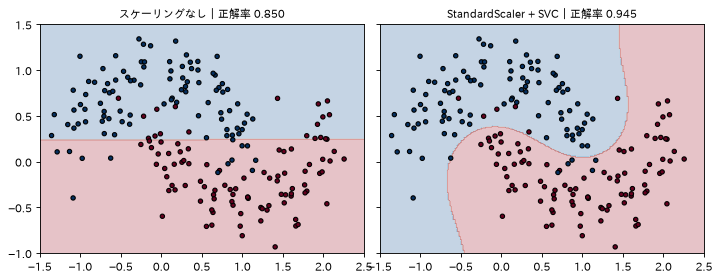

In [6]:
Xm, ym = make_moons(n_samples=200, noise=0.2, random_state=0)
scale = np.array([1, 100])
raw = svm.SVC().fit(Xm * scale, ym)                                 # 2 番目の特徴だけ 100 倍のまま学習
piped = make_pipeline(StandardScaler(), svm.SVC()).fit(Xm * scale, ym)

xx, yy = np.meshgrid(np.linspace(-1.5, 2.5, 250), np.linspace(-1, 1.5, 250))
grid_s = np.c_[xx.ravel(), yy.ravel()] * scale
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharey=True)
for ax, (title, m) in zip(axes, [("スケーリングなし", raw), ("StandardScaler + SVC", piped)]):
    ax.contourf(xx, yy, m.predict(grid_s).reshape(xx.shape), alpha=0.25, cmap="RdBu_r")
    ax.scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap="RdBu_r", edgecolor="k", s=15)
    ax.set_title(f"{title}｜正解率 {m.score(Xm * scale, ym):.3f}", fontsize=10); ax.grid(False)
plt.tight_layout(); plt.show()

👀 スケーリングなし（左）では、値の大きい 2 番目の特徴（縦軸）だけで距離が決まるので、学習した境界は**ほぼ水平の帯**になり、三日月の形を捉えられていません。標準化すると（右）、両方の特徴が同じ重みで効き、三日月に沿った境界になります。

### 🧪 ⑥ `nu` の意味

`NuSVC` で `nu` を変え、「サポートベクターの割合」と「マージン誤差の割合」を数えます（マージン誤差は、双対係数が上限に張り付いたサンプル。4 章で説明します）。ガイドの 4 章によると、`nu` は**マージン誤差の割合の上限**、かつ**サポートベクターの割合の下限**です。

In [7]:
Xb, yb = make_classification(n_samples=300, n_features=5, flip_y=0.2, random_state=0)
rows = []
for nu in [0.1, 0.3, 0.5, 0.7]:
    m = svm.NuSVC(nu=nu).fit(Xb, yb)
    a = np.abs(m.dual_coef_[0])
    bounded = np.isclose(a, a.max(), rtol=1e-6).sum()            # 上限に張り付いた双対係数 = マージン誤差
    rows.append({"nu": nu, "マージン誤差の割合": bounded / len(Xb), "サポートベクターの割合": len(m.support_) / len(Xb)})
df_nu = pd.DataFrame(rows).set_index("nu")
df_nu["マージン誤差 ≤ nu ≤ SV の割合"] = (df_nu["マージン誤差の割合"] <= df_nu.index) & (df_nu.index <= df_nu["サポートベクターの割合"])
df_nu

,マージン誤差の割合,サポートベクターの割合,マージン誤差 ≤ nu ≤ SV の割合
nu,,,
0.1,0.0100,0.4567,True
0.3,0.2300,0.4133,True
0.5,0.4667,0.5233,True
0.7,0.6867,0.7167,True


👀 どの `nu` でも「マージン誤差の割合 ≤ `nu` ≤ サポートベクターの割合」が成り立ちました。`C` は「はみ出しの罰の重さ」で直感がつかみにくいのに対し、`nu` は「**だいたいこのくらいの割合のサンプルを、サポートベクター / 誤差として許す**」と割合で指定できるのが利点です。

### 🧪 ⑧ `LinearSVC` の乱数

`dual=True` のとき、`random_state` だけを変えて学習し、係数の差の最大値を見ます。

In [8]:
Xr, yr = make_classification(n_samples=200, n_features=50, random_state=1)
rows = []
for dual, tol in [(True, 1e-4), (True, 1e-8), (False, 1e-4)]:
    c1 = svm.LinearSVC(dual=dual, tol=tol, random_state=0, max_iter=100000).fit(Xr, yr).coef_
    c2 = svm.LinearSVC(dual=dual, tol=tol, random_state=1, max_iter=100000).fit(Xr, yr).coef_
    rows.append({"dual": dual, "tol": tol, "random_state を変えたときの係数の差（最大）": np.abs(c1 - c2).max()})
pd.DataFrame(rows)

,dual,tol,random_state を変えたときの係数の差（最大）
0,True,1.0000e-04,4.5980e-06
1,True,1.0000e-08,2.8344e-10
2,False,1.0000e-04,0.0000e+00


👀 `dual=True` では、`random_state` を変えると係数がわずかに違います。`tol` を小さくすると差はさらに小さくなります（ガイドのとおり）。`dual=False` では差がちょうど 0 で、乱数を使っていないことが分かります。

### 🧪 ⑨ L1 正則化の `LinearSVC` と `l1_min_c`

全部の重みが 0 になる C の上限（l1_min_c）: 0.00238


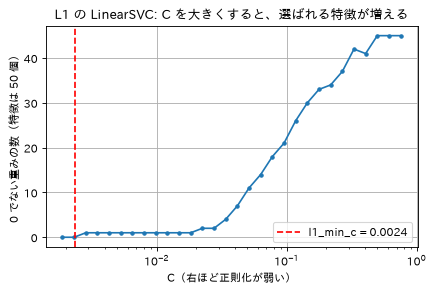

In [9]:
from sklearn.svm import l1_min_c
c_min = l1_min_c(Xr, yr, loss="squared_hinge")
print(f"全部の重みが 0 になる C の上限（l1_min_c）: {c_min:.5f}")
Cs = c_min * np.logspace(-0.1, 2.5, 30)
nonzero = [(svm.LinearSVC(penalty="l1", dual=False, C=C).fit(Xr, yr).coef_ != 0).sum() for C in Cs]
plt.semilogx(Cs, nonzero, marker=".")
plt.axvline(c_min, color="red", ls="--", label=f"l1_min_c = {c_min:.4f}")
plt.xlabel("C（右ほど正則化が弱い）"); plt.ylabel("0 でない重みの数（特徴は 50 個）")
plt.legend(); plt.title("L1 の LinearSVC: C を大きくすると、選ばれる特徴が増える"); plt.show()

👀 `C` が `l1_min_c` より小さいと、すべての重みが 0（何も選ばない「空のモデル」）です。`C` を大きくする（正則化を弱める）と、使う特徴が 1 個、2 個…と増えていきます。1.1 の Lasso の正則化パスと同じ現象で、`C` が正則化の**逆**の強さであることも確かめられます。

---
## 3. カーネル関数（1.4.6 Kernel functions）

### 📖 ガイドの解説

カーネル関数には、次のどれかを使えます。

| `kernel` | 式 | 引数 |
|---|---|---|
| `"linear"` | $\langle x, x' \rangle$ | — |
| `"poly"`（多項式） | $(\gamma \langle x, x' \rangle + r)^d$ | $d$ = `degree`、$r$ = `coef0` |
| `"rbf"` | $\exp(-\gamma \lVert x - x' \rVert^2)$ | $\gamma$ = `gamma`（0 より大きい） |
| `"sigmoid"` | $\tanh(\gamma \langle x, x' \rangle + r)$ | $r$ = `coef0` |

カーネルの種類は `kernel` 引数で指定します。RBF カーネルを、ずっと速くスケーラブルに使う方法として、「6.7 カーネル近似」も参照してください。

### 🔢 数式を読む

| 記号 | 意味 |
|---|---|
| $\langle x, x' \rangle$ | 2 点の内積（要素ごとの積の和）。向きが似ているほど大きい |
| $\lVert x - x' \rVert^2$ | 2 点の距離の二乗 |
| $\gamma$ | どのカーネルでも「似ている度合いの感度」。`gamma='scale'`（既定）だと $1 / (n_\text{features} \times \operatorname{Var}(X))$ |
| $\tanh$ | 双曲線正接。値を −1〜1 につぶす S 字の関数 |

**日本語で読むと**: 線形は「内積そのもの」、多項式は「内積を $d$ 乗」（特徴の掛け算を $d$ 個まで考える）、RBF は「距離が近いほど 1」、シグモイドは「内積を S 字でつぶしたもの」（ニューラルネットワークの活性化関数に由来）。

> 📚 **用語**: **`gamma='scale'`** — `SVC` の既定値。特徴の数とデータの分散から `gamma` を自動で決める。データのスケールに合わせてくれるが、スケーリング（2 章 ④）の代わりにはならない。

In [10]:
linear_svc = svm.SVC(kernel='linear')
print(linear_svc.kernel)
rbf_svc = svm.SVC(kernel='rbf')
print(rbf_svc.kernel)

linear
rbf


#### 📈 学習したモデルを見る: 4 つのカーネルの境界

直線では分けられない 2 種類のデータ（三日月と同心円）で、4 つのカーネルが学習した境界を並べます。

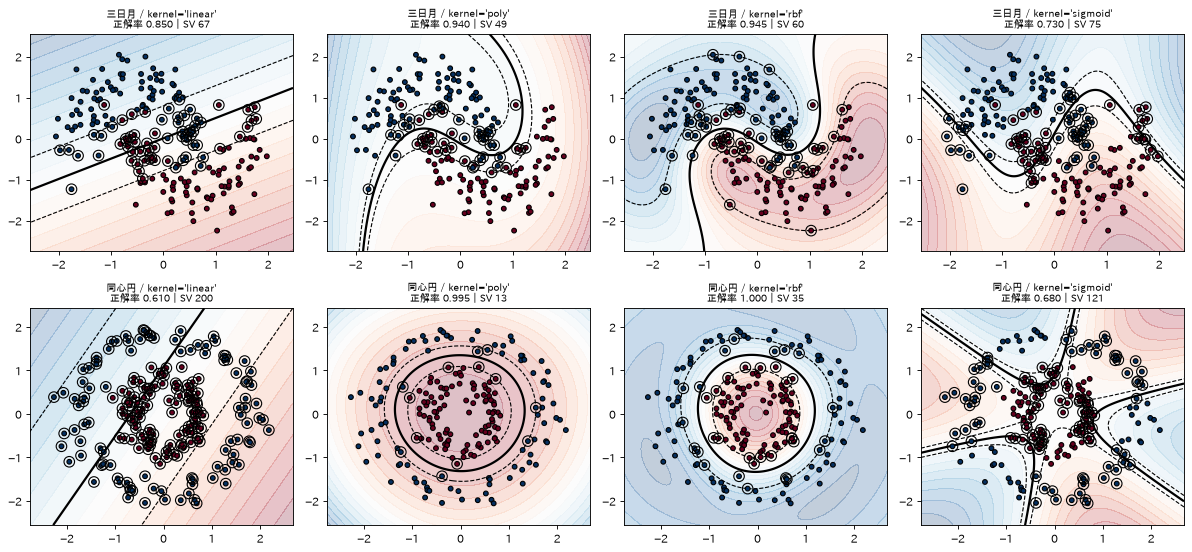

In [11]:
datasets = [("三日月", make_moons(n_samples=200, noise=0.2, random_state=0)),
            ("同心円", make_circles(n_samples=200, noise=0.1, factor=0.4, random_state=0))]
kernels = [("linear", {}), ("poly", dict(degree=3, coef0=1)), ("rbf", {}), ("sigmoid", dict(coef0=0))]
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for i, (dname, (Xk, yk)) in enumerate(datasets):
    Xk = StandardScaler().fit_transform(Xk)
    for j, (kname, kw) in enumerate(kernels):
        m = svm.SVC(kernel=kname, **kw).fit(Xk, yk)
        plot_svc(axes[i, j], m, Xk, yk, f"{dname} / kernel='{kname}'\n正解率 {m.score(Xk, yk):.3f}｜SV {len(m.support_)}")
plt.tight_layout(); plt.show()

### 👀 結果の読み方

- **linear**: どちらのデータでも直線しか引けず、うまく分けられません。
- **poly**（3 次）: 三日月をおおむね曲線で分けています。同心円も、多項式の曲線で内側と外側を分けられています。
- **rbf**: どちらのデータでも、形に沿った境界を学習しています。ほとんどの問題でまず試すべきカーネルで、`SVC` の既定です。
- **sigmoid**: どちらのデータでもうまく分けられていません。シグモイドカーネルは数学的に「正しいカーネル」（1.3 のマーサーの条件）を満たさない場合があり、実際にはあまり使われません。

### 1.4.6.1 RBF カーネルのパラメータ

📖 RBF カーネルで SVM を学習するときは、`C` と `gamma` の 2 つのパラメータを考える必要があります。

- `C` はすべてのカーネルに共通で、**学習データの誤分類**と**決定面の単純さ**のバランスをとります。`C` が小さいと決定面はなめらかになり、`C` が大きいとすべての学習データを正しく分類しようとします。
- `gamma` は、**1 つの学習データがどれだけ遠くまで影響するか**を決めます。`gamma` が大きいほど、影響を受けるにはほかのデータが近くにいる必要があります。

`C` と `gamma` の適切な選び方は、SVM の性能にとって決定的です。`GridSearchCV` で、`C` と `gamma` を**指数的に離れた値**（10 倍ずつなど）で探すことが勧められています。

#### 📈 学習したモデルを見る: ガイドの例「RBF SVM parameters」

ガイドの例と同じく、アヤメのうち 2 品種（versicolor と virginica）の 2 特徴（標準化済み）で、`C` と `gamma` を 10 倍ずつ変えたときの境界を並べます。

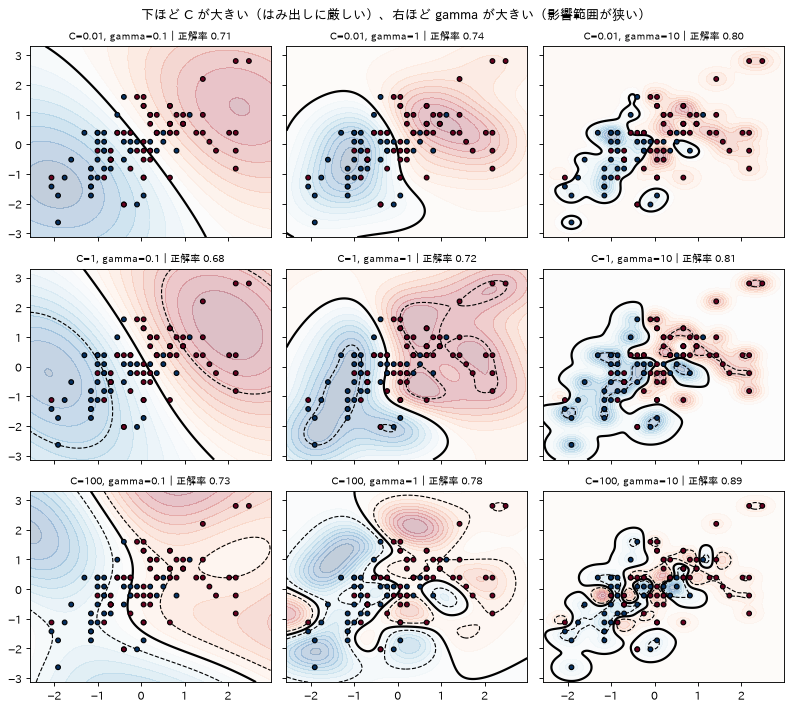

In [12]:
iris = load_iris()
mask = iris.target != 0                                     # versicolor と virginica
X2 = StandardScaler().fit_transform(iris.data[mask][:, :2])
y2 = iris.target[mask] - 1
fig, axes = plt.subplots(3, 3, figsize=(10, 9), sharex=True, sharey=True)
for i, C in enumerate([1e-2, 1, 1e2]):
    for j, gamma in enumerate([1e-1, 1, 1e1]):
        m = svm.SVC(C=C, gamma=gamma).fit(X2, y2)
        plot_svc(axes[i, j], m, X2, y2, f"C={C:g}, gamma={gamma:g}｜正解率 {m.score(X2, y2):.2f}", show_sv=False)
fig.suptitle("下ほど C が大きい（はみ出しに厳しい）、右ほど gamma が大きい（影響範囲が狭い）")
plt.tight_layout(); plt.show()

### 👀 結果の読み方

- **右列（`gamma=10`）**: 1 つ 1 つの点の影響範囲が狭いので、点のまわりに小さな島のような領域ができます。特に `C` が大きい右下は、学習データをほぼ丸暗記した**過学習**の状態です（学習データの正解率は高いが、新しいデータには通用しない）。
- **左列（`gamma=0.1`）**: 影響範囲が広いので、境界はほぼ直線に近いなめらかな形になります。
- **上段（`C=0.01`）**: はみ出しをほとんど気にしないので、`gamma` が小さいと境界が単純になりすぎます。
- 学習データの正解率だけを見ると、右下がいちばん良く見えますが、それは過学習によるものです。**良い組み合わせは、見ていないデータで確かめる**必要があります（次のセル）。

### 🧪 やってみよう / 📈: 交差検証で `C` と `gamma` を選ぶ

ガイドの例と同じく、ここでは**アヤメの全データ（3 品種・4 特徴、標準化済み）**を使い、`C` と `gamma` をそれぞれ 13 段階（10 倍刻み）で探して、交差検証の正解率をヒートマップにします。

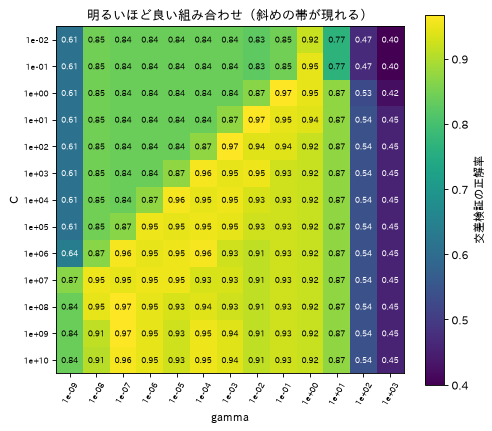

選ばれた組み合わせ: {'C': np.float64(1.0), 'gamma': np.float64(0.1)} / 交差検証の正解率: 0.967


In [13]:
from sklearn.model_selection import StratifiedShuffleSplit
X_all = StandardScaler().fit_transform(iris.data); y_all = iris.target
C_range = np.logspace(-2, 10, 13)
gamma_range = np.logspace(-9, 3, 13)
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)     # ガイドの例と同じ分割
search = GridSearchCV(svm.SVC(), {"C": C_range, "gamma": gamma_range}, cv=cv).fit(X_all, y_all)
scores = search.cv_results_["mean_test_score"].reshape(len(C_range), len(gamma_range))

plt.figure(figsize=(7, 6)); plt.imshow(scores, cmap="viridis", vmin=0.4)
plt.xticks(range(len(gamma_range)), [f"{g:.0e}" for g in gamma_range], rotation=60, fontsize=7)
plt.yticks(range(len(C_range)), [f"{c:.0e}" for c in C_range], fontsize=7)
plt.xlabel("gamma"); plt.ylabel("C"); plt.colorbar(label="交差検証の正解率"); plt.grid(False)
for (i, j), v in np.ndenumerate(scores):
    plt.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7, color="white" if v < 0.7 else "black")
plt.title("明るいほど良い組み合わせ（斜めの帯が現れる）"); plt.show()
print("選ばれた組み合わせ:", search.best_params_, "/ 交差検証の正解率:", round(search.best_score_, 3))

👀 成績の良い組み合わせ（0.95 前後の明るいマス）は、**右上から左下への斜めの帯**の上に並びます。図の上ほど `C` が小さく、右ほど `gamma` が大きいので、「`C` が小さい（正則化が強い）なら `gamma` は大きめ、`C` が大きいなら `gamma` は小さめ」が良い組み合わせです。`gamma` を大きくして境界を複雑にしても、`C` を小さくしてはみ出しを許せば釣り合いがとれる、という関係で、ガイドの例も同じ形の図を示しています。

- **右下**（`gamma` も `C` も大きい）: 過学習で、正解率が大きく下がります。
- **左上**（両方小さい）: 境界が単純すぎて、やはり正解率が下がります。
- **右端の列**（`gamma` が非常に大きい）: `C` に関係なく悪く、1 点ずつ丸暗記している状態です。

💡 2 特徴・2 品種のデータ（上の 3×3 の図）でも同じグリッドサーチを試しましたが、データの重なりが大きく、どの組み合わせでも正解率 0.7 前後にとどまり、帯ははっきり現れませんでした。**ハイパーパラメータの効き方は、データに十分な情報があって初めて見える**ことも覚えておきましょう。

### 1.4.6.2 独自のカーネル

📖 カーネルは、**Python の関数**として渡すか、**グラム行列**を事前に計算して渡すことで、自分で定義できます。独自のカーネルを使う分類器は、次の点を除いて、ほかの分類器と同じように動きます。

- `support_vectors_` 属性は空になり、サポートベクターの番号だけが `support_` に保存される。
- `fit()` メソッドの第 1 引数の**コピーではなく参照**が、後で使うために保存される。その配列を `fit()` と `predict()` の間に書き換えると、予期しない結果になる。

**Python の関数をカーネルに使う**: `kernel` 引数に関数を渡します。関数は、形 `(n_samples_1, n_features)` と `(n_samples_2, n_features)` の 2 つの行列を受け取り、形 `(n_samples_1, n_samples_2)` のカーネル行列を返す必要があります。

**グラム行列を使う**: `kernel='precomputed'` を指定し、`fit` と `predict` に `X` の代わりにグラム行列を渡します。学習データどうしと、テストデータと学習データの間のカーネルの値を、すべて用意する必要があります。

> 📚 **用語**: **グラム行列** — データの全ペアについてのカーネルの値を並べた行列（1.3 のカーネル行列と同じ）。予測のときは「テストデータ × 学習データ」の形の行列を渡す。

In [14]:
def my_kernel(X, Y):
    return np.dot(X, Y.T)                      # 線形カーネルを自分で書いたもの

clf_custom = svm.SVC(kernel=my_kernel).fit(X2, y2)
clf_linear = svm.SVC(kernel="linear").fit(X2, y2)
print("独自カーネルの support_vectors_ の形:", clf_custom.support_vectors_.shape, "/ support_ の数:", len(clf_custom.support_))
print("kernel='linear' と予測が一致:", (clf_custom.predict(X2) == clf_linear.predict(X2)).all())

# ガイドのコード例: 事前に計算したグラム行列
X, y = make_classification(n_samples=10, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
clf = svm.SVC(kernel='precomputed')
gram_train = np.dot(X_train, X_train.T)          # 学習データ × 学習データ
clf.fit(gram_train, y_train)
gram_test = np.dot(X_test, X_train.T)            # テストデータ × 学習データ
print("precomputed の予測:", clf.predict(gram_test))
assert (clf.predict(gram_test) == [0, 1, 0]).all()   # ガイドの出力と一致

独自カーネルの support_vectors_ の形: (0, 0) / support_ の数: 67
kernel='linear' と予測が一致: True
precomputed の予測: [0 1 0]


👀 独自のカーネルでは `support_vectors_` が空（形 `(0, 0)`）になり、`support_`（番号）だけが残ります。中身は線形カーネルなので、`kernel='linear'` と同じ予測になりました。

🏭 **独自のカーネルの利用例**: 文字列（DNA の塩基配列、文章）やグラフ（分子の構造）など、数値のベクトルで表しにくいデータどうしの「似ている度合い」を、専用のカーネル（文字列カーネル、グラフカーネル）で定義して SVM で分類する研究は、生物情報学や化学で広く行われてきました。

---
## 4. 数式（1.4.7 Mathematical formulation）

### 📖 ガイドの解説

サポートベクターマシンは、高次元（無限次元のこともある）の空間に、1 つまたは複数の**超平面**を作ります。これを分類や回帰などに使います。直感的には、**どのクラスでも最も近い学習データまでの距離が最大になる超平面**（いわゆる関数マージン）で、良い分離が得られます。一般に、マージンが大きいほど、分類器の汎化誤差が小さくなるからです。

ガイドの図は、線形に分離できる問題の決定関数を示しています。マージンの境界上に 3 つのサンプルがあり、これを「サポートベクター」と呼びます（1/2 の最初の図と同じ）。一般に、線形に分離できない問題では、サポートベクターは**マージンの境界の内側**にあるサンプルです。

SVM の理論と実践については、Bishop の教科書の 7 章と、Smola と Schölkopf の SVR のチュートリアルが良い参考文献として勧められています。

> 📚 **用語**
> - **超平面（hyperplane）**: 2 次元では直線、3 次元では平面、それ以上の次元での「平らな境界」。$w^T x + b = 0$ で表される。
> - **汎化誤差**: 学習に使っていない新しいデータでの誤差。

### 1.4.7.1 SVC

📖 2 つのクラスの学習ベクトル $x_i \in \mathbb{R}^p$（$i = 1, \dots, n$）と、ベクトル $y \in \{1, -1\}^n$ が与えられたとき、予測 $\operatorname{sign}(w^T \phi(x) + b)$ がほとんどのサンプルで正しくなるような $w \in \mathbb{R}^p$ と $b \in \mathbb{R}$ を見つけることが目的です。`SVC` は次の**主問題**を解きます。

$$\begin{aligned}
\min_{w, b, \zeta} \quad & \frac{1}{2} w^T w + C \sum_{i=1}^{n} \zeta_i \\
\text{subject to} \quad & y_i (w^T \phi(x_i) + b) \geq 1 - \zeta_i, \\
& \zeta_i \geq 0, \quad i = 1, \dots, n
\end{aligned}$$

直感的には、$\|w\|^2 = w^T w$ を最小化することで**マージンを最大化**しつつ、サンプルが誤分類されたり、マージンの境界の内側に入ったりしたときに罰を受けます。理想的には、すべてのサンプルで $y_i (w^T \phi(x_i) + b)$ が 1 以上になり、これは完全な予測を意味します。しかし実際の問題は、超平面で完全に分けられるとは限らないので、一部のサンプルが正しいマージンの境界から距離 $\zeta_i$ だけ離れることを許します。罰則の項 `C` がこの罰の強さを決めるので、`C` は**正則化パラメータの逆数**のように働きます。

### 🔢 数式を読む: SVC の主問題

| 記号 | 意味 |
|---|---|
| $y_i \in \{1, -1\}$ | サンプル $i$ の正解（クラスを +1 と −1 で表す） |
| $\phi(x_i)$ | 特徴空間への変換（カーネルで暗に計算される） |
| $w^T \phi(x_i) + b$ | 決定関数の値（`decision_function`）。符号がクラス |
| $y_i (w^T \phi(x_i) + b)$ | 「正しい側にどれだけ深く入っているか」。正なら正しく分類、1 以上ならマージンの外 |
| $\frac{1}{2} w^T w$ | マージンの狭さ。マージンの幅は $2 / \lVert w \rVert$ なので、$\lVert w \rVert$ を小さくするとマージンが広がる |
| $\zeta_i \ge 0$ | **スラック変数**: サンプル $i$ がマージンからどれだけはみ出したか。マージンの外なら 0、境界とマージンの間なら 0〜1、反対側（誤分類）なら 1 より大きい |
| $C \sum_i \zeta_i$ | はみ出しの合計に対する罰。$C$ が大きいほど、はみ出しを許さない |

**日本語で読むと**: 「道路の幅をできるだけ広くしたい（$\frac{1}{2} w^T w$ を小さく）」と「道路にはみ出す家をできるだけ少なくしたい（$C \sum \zeta_i$ を小さく）」の釣り合いを、$C$ で決める。

> 📚 **用語**: **スラック変数（slack variable）** — 「ゆるみ」の変数。厳しい条件（全部をマージンの外に）を満たせないときに、どれだけ破ってよいかを表す。$\zeta$ はギリシャ文字のゼータ。

#### 📈 学習したモデルを見る: `C` によるマージンの変化と、スラック変数

重なりのある 2 クラスのデータで、`C` を変えて学習した線形 SVM のマージンと、各サンプルのスラック変数 $\zeta_i = \max(0, 1 - y_i f(x_i))$ を描きます。

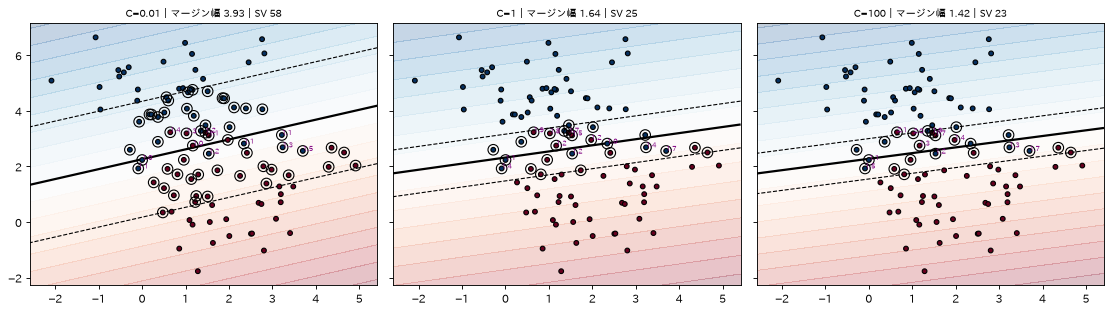

,マージン幅 2/||w||,サポートベクター数,Σζ（はみ出しの合計）,誤分類の数（ζ>1）,学習データの正解率
C,,,,,
0.01,3.9284,58,31.9002,12,0.88
1.00,1.6425,25,21.5055,12,0.88
100.00,1.4242,23,21.4188,11,0.89


In [15]:
Xo, yo = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=1.2)
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
rows = []
for ax, C in zip(axes, [0.01, 1, 100]):
    m = svm.SVC(kernel="linear", C=C).fit(Xo, yo)
    f = m.decision_function(Xo)
    zeta = np.maximum(0, 1 - np.where(yo == 1, 1, -1) * f)        # スラック変数
    plot_svc(ax, m, Xo, yo, f"C={C}｜マージン幅 {2 / np.linalg.norm(m.coef_):.2f}｜SV {len(m.support_)}")
    for i in np.flatnonzero(zeta > 1):                             # 誤分類（ζ > 1）に印
        ax.annotate(f"{zeta[i]:.1f}", Xo[i], fontsize=6, color="purple")
    rows.append({"C": C, "マージン幅 2/||w||": 2 / np.linalg.norm(m.coef_), "サポートベクター数": len(m.support_),
                 "Σζ（はみ出しの合計）": zeta.sum(), "誤分類の数（ζ>1）": (zeta > 1).sum(), "学習データの正解率": m.score(Xo, yo)})
plt.tight_layout(); plt.show()
pd.DataFrame(rows).set_index("C")

### 👀 結果の読み方

- **`C=0.01`**（左）: はみ出しの罰が軽いので、マージン（点線の間）を広くとり、多くの点がマージンの中に入っています。マージンの中や反対側の点はすべてサポートベクター（丸印）なので、その数も多くなります。
- **`C=100`**（右）: はみ出しに厳しいので、マージンが狭くなり、サポートベクターも減ります。
- 紫の数字は、誤分類された点（$\zeta > 1$）のスラック変数の値です。$\zeta$ が大きい点ほど、反対側に深く入り込んでいます。
- 表のとおり、`C` を大きくするほど「マージン幅」と「はみ出しの合計 $\sum \zeta$」が小さくなります。これが主問題の 2 つの項の釣り合いです。

### 📖 双対問題

主問題の**双対問題**は次のとおりです。

$$\begin{aligned}
\min_{\alpha} \quad & \frac{1}{2} \alpha^T Q \alpha - e^T \alpha \\
\text{subject to} \quad & y^T \alpha = 0, \\
& 0 \leq \alpha_i \leq C, \quad i = 1, \dots, n
\end{aligned}$$

ここで $e$ はすべての要素が 1 のベクトル、$Q$ は $n \times n$ の半正定値行列で、$Q_{ij} \equiv y_i y_j K(x_i, x_j)$、$K(x_i, x_j) = \phi(x_i)^T \phi(x_j)$ がカーネルです。$\alpha_i$ を**双対係数**と呼び、上限は $C$ です。この双対表現から、学習ベクトルが関数 $\phi$ によって、より高い（無限かもしれない）次元の空間に暗に写されていることが分かります（カーネルトリック）。

最適化問題を解くと、サンプル $x$ に対する `decision_function` の出力は次のようになります。

$$\sum_{i \in SV} y_i \alpha_i K(x_i, x) + b$$

予測されるクラスはその符号です。サポートベクター（マージンの内側にあるサンプル）だけについて足せばよいのは、それ以外のサンプルの双対係数 $\alpha_i$ が 0 だからです。これらのパラメータには、属性 `dual_coef_`（積 $y_i \alpha_i$ を保持）、`support_vectors_`（サポートベクター）、`intercept_`（独立の項 $b$）でアクセスできます。

### 🔢 数式を読む: 双対問題と決定関数

| 記号 | 意味 | scikit-learn |
|---|---|---|
| $\alpha_i$ | サンプル $i$ の双対係数（「発言力」）。0 なら予測に無関係 | — |
| $0 \le \alpha_i \le C$ | 発言力には上限 $C$ がある。$\alpha_i = C$ はマージン誤差（はみ出した点）、$0 < \alpha_i < C$ はマージンの境界上の点 | — |
| $y^T \alpha = 0$ | 正のクラスと負のクラスの発言力の合計が等しい | — |
| $Q_{ij} = y_i y_j K(x_i, x_j)$ | 正解の符号を掛けたカーネル行列 | — |
| $y_i \alpha_i$ | 符号付きの発言力 | `dual_coef_` |
| $x_i$（$\alpha_i > 0$ のもの） | サポートベクター | `support_vectors_` |
| $b$ | 切片 | `intercept_` |

**日本語で読むと**: 予測は「新しい点と各サポートベクターの似ている度合い」×「そのサポートベクターの符号付きの発言力」の合計に、切片を足したもの。1.3 のカーネルリッジ回帰と同じ形ですが、発言力が 0 でないのはサポートベクターだけです（スパース）。

### 🧪 やってみよう: `decision_function` を手で計算する

In [16]:
gamma, C = 0.5, 1.0
s = svm.SVC(kernel="rbf", gamma=gamma, C=C).fit(Xb, yb)
manual = rbf_kernel(Xb, s.support_vectors_, gamma=gamma) @ s.dual_coef_[0] + s.intercept_[0]
print("手計算 Σ y_i α_i K(x_i, x) + b と decision_function が一致:", np.allclose(manual, s.decision_function(Xb)))
a = np.abs(s.dual_coef_[0])                                   # |y_i α_i| = α_i
print(f"サポートベクター {len(a)} 個のうち、α_i = C（上限に張り付き = マージン誤差）: {np.isclose(a, C).sum()} 個,"
      f" 0 < α_i < C（マージンの境界上）: {(~np.isclose(a, C)).sum()} 個")
print("すべて 0 ≤ α_i ≤ C:", ((a >= 0) & (a <= C + 1e-9)).all())
print("y^T α = 0（dual_coef_ の合計）:", np.isclose(s.dual_coef_.sum(), 0))

手計算 Σ y_i α_i K(x_i, x) + b と decision_function が一致: True
サポートベクター 151 個のうち、α_i = C（上限に張り付き = マージン誤差）: 85 個, 0 < α_i < C（マージンの境界上）: 66 個
すべて 0 ≤ α_i ≤ C: True
y^T α = 0（dual_coef_ の合計）: True


👀 手計算が `decision_function` と一致し、双対係数が $0 \le \alpha_i \le C$ と $y^T \alpha = 0$ の制約を満たしていることを確かめられました。ノイズの多いデータなので、サポートベクターの多くが上限 $C$ に張り付いた（マージンからはみ出した）点です。

> 📖 **ノート**: libsvm と liblinear 由来の SVM のモデルは正則化パラメータに `C` を使いますが、ほかの多くの推定器は `alpha` を使います。2 つのモデルの正則化の強さの正確な対応は、それぞれのモデルが最適化する目的関数によって決まります。たとえば `Ridge` 回帰の場合、関係は $C = \frac{1}{\alpha}$ です。

#### 📖 LinearSVC

主問題は、次のように同じ意味で書き直せます。

$$\min_{w, b} \frac{1}{2} w^T w + C \sum_{i=1}^{n} \max(0, 1 - y_i (w^T \phi(x_i) + b))$$

ここでは**ヒンジ損失**を使っています。これが `LinearSVC` が直接最適化する形です。ただし双対形と違って、サンプルどうしの内積が出てこないので、有名なカーネルトリックは使えません。そのため、`LinearSVC` は線形カーネルにしか対応していません（$\phi$ は恒等関数）。

### 🔢 数式を読む: ヒンジ損失

$\max(0, 1 - y_i f(x_i))$ は、上で見たスラック変数 $\zeta_i$ そのものです。「マージンの外（$y_i f(x_i) \ge 1$）なら 0、内側に入った分だけ直線的に罰する」損失で、蝶番（ヒンジ）のように 1 の地点で折れ曲がった形をしています。`LinearSVC` の既定は、これを**二乗した**損失（`squared_hinge`）です。

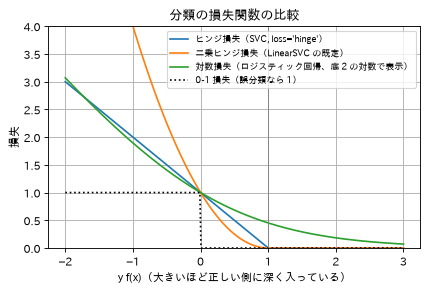

In [17]:
m_ = np.linspace(-2, 3, 300)                      # m = y f(x)（正しい側にどれだけ深く入っているか）
plt.plot(m_, np.maximum(0, 1 - m_), label="ヒンジ損失（SVC, loss='hinge'）")
plt.plot(m_, np.maximum(0, 1 - m_) ** 2, label="二乗ヒンジ損失（LinearSVC の既定）")
plt.plot(m_, np.log2(1 + np.exp(-m_)), label="対数損失（ロジスティック回帰、底 2 の対数で表示）")
plt.plot(m_, (m_ < 0).astype(float), "k:", label="0-1 損失（誤分類なら 1）")
plt.axvline(1, color="gray", lw=0.8); plt.ylim(0, 4)
plt.xlabel("y f(x)（大きいほど正しい側に深く入っている）"); plt.ylabel("損失"); plt.legend(fontsize=8)
plt.title("分類の損失関数の比較"); plt.show()

👀 どの損失も、$y f(x)$ が大きい（正しい側に深い）ほど小さくなります。ヒンジ損失は $y f(x) \ge 1$ で**ちょうど 0** になるので、マージンの外の点は学習に影響しません（スパースになる理由）。対数損失はどこでも 0 にはならないので、ロジスティック回帰はすべての点の影響を受けます。二乗ヒンジ損失は、マージンの内側に入った点をより強く罰します。

#### 🧪 やってみよう / 📈: `LinearSVC` は切片も正則化する

1/2 で触れた「`LinearSVC` は切片も正則化する」を確かめます。原点から遠い場所（x = 8 と x = 12 付近）にある 1 次元のデータで、`C` を小さくして学習します。本当の境界は x = 10 付近です。

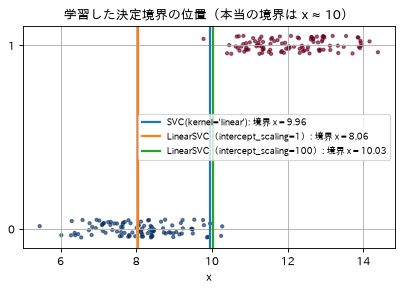

In [18]:
rng = np.random.RandomState(0)
x1 = np.r_[rng.normal(8, 1, 100), rng.normal(12, 1, 100)][:, None]
y1 = np.r_[np.zeros(100), np.ones(100)]
models_b = [("SVC(kernel='linear')", svm.SVC(kernel="linear", C=0.01)),
            ("LinearSVC（intercept_scaling=1）", svm.LinearSVC(C=0.01, intercept_scaling=1)),
            ("LinearSVC（intercept_scaling=100）", svm.LinearSVC(C=0.01, intercept_scaling=100))]
plt.scatter(x1[:, 0], y1 + rng.uniform(-0.05, 0.05, 200), s=8, c=y1, cmap="RdBu_r", alpha=0.6)
for k, (name, m) in enumerate(models_b):
    m.fit(x1, y1)
    boundary = -m.intercept_[0] / m.coef_[0, 0]
    plt.axvline(boundary, color=f"C{k}", lw=2, label=f"{name}: 境界 x = {boundary:.2f}")
plt.legend(fontsize=8); plt.xlabel("x"); plt.yticks([0, 1]); plt.title("学習した決定境界の位置（本当の境界は x ≈ 10）"); plt.show()

👀 `SVC` と `intercept_scaling=100` の `LinearSVC` は、境界をほぼ x = 10 に置いています。既定（`intercept_scaling=1`）の `LinearSVC` は、境界が大きく左にずれました。切片 $b$ が正則化で 0 の方向に引っ張られ、データが原点から遠いと、それが境界のずれとして現れるからです。

💡 `intercept_scaling` は、liblinear の内部で「値がすべて `intercept_scaling` の特徴」を 1 列加え、その係数として切片を学習する仕組みです。この値を大きくすると、同じ切片を小さな係数で表せるので、正則化の影響が小さくなります。データを標準化（平均 0）しておけば、切片はもともと 0 付近になるので、この問題は起きにくくなります。

#### 📖 NuSVC

$\nu$-SVC の定式化（Schölkopf ら, 2000）は、$C$-SVC のパラメータを置き換えたもので、数学的には**同等**です。$C$ の代わりに、サポートベクターとマージン誤差の数を制御する新しいパラメータ $\nu$ を導入します。$\nu \in (0, 1]$ は、**マージン誤差の割合の上限**であり、**サポートベクターの割合の下限**です。マージン誤差とは、マージンの境界の間違った側にあるサンプルのことで、誤分類されているか、正しく分類されていてもマージンの外側にないサンプルです。

（2 章 ⑥ の実験で、この性質を確かめました。）

### 1.4.7.2 SVR

📖 学習ベクトル $x_i \in \mathbb{R}^p$（$i = 1, \dots, n$）とベクトル $y \in \mathbb{R}^n$ が与えられたとき、$\varepsilon$-SVR は次の主問題を解きます。

$$\begin{aligned}
\min_{w, b, \zeta, \zeta^*} \quad & \frac{1}{2} w^T w + C \sum_{i=1}^{n} (\zeta_i + \zeta_i^*) \\
\text{subject to} \quad & y_i - w^T \phi(x_i) - b \leq \varepsilon + \zeta_i, \\
& w^T \phi(x_i) + b - y_i \leq \varepsilon + \zeta_i^*, \\
& \zeta_i, \zeta_i^* \geq 0, \quad i = 1, \dots, n
\end{aligned}$$

ここでは、予測が本当の値から少なくとも $\varepsilon$ 離れたサンプルを罰しています。そうしたサンプルは、予測が $\varepsilon$-チューブの上にあるか下にあるかによって、$\zeta_i$ または $\zeta_i^*$ だけ目的関数を増やします。

### 🔢 数式を読む: SVR の主問題

| 記号 | 意味 |
|---|---|
| $\varepsilon$ | チューブの半分の幅（`epsilon`）。この範囲のずれは罰しない |
| $\zeta_i$ | 実際の値が予測より $\varepsilon$ 以上**上**にはみ出した量 |
| $\zeta_i^*$ | 実際の値が予測より $\varepsilon$ 以上**下**にはみ出した量 |
| $\frac{1}{2} w^T w$ | 関数の平らさ（係数が小さいほどなめらか） |

**日本語で読むと**: 「できるだけ平らな関数で」かつ「ε-チューブからはみ出す量の合計をできるだけ小さく」。1.3 の ε-不感損失を、スラック変数を使って制約の形で書いたもの。

📖 双対問題は次のとおりです（$e$ はすべて 1 のベクトル、$Q_{ij} \equiv K(x_i, x_j)$）。

$$\begin{aligned}
\min_{\alpha, \alpha^*} \quad & \frac{1}{2} (\alpha - \alpha^*)^T Q (\alpha - \alpha^*) + \varepsilon e^T (\alpha + \alpha^*) - y^T (\alpha - \alpha^*) \\
\text{subject to} \quad & e^T (\alpha - \alpha^*) = 0, \\
& 0 \leq \alpha_i, \alpha_i^* \leq C, \quad i = 1, \dots, n
\end{aligned}$$

予測は次のとおりです。

$$\sum_{i \in SV} (\alpha_i - \alpha_i^*) K(x_i, x) + b$$

これらのパラメータには、属性 `dual_coef_`（差 $\alpha_i - \alpha_i^*$ を保持）、`support_vectors_`、`intercept_`（$b$）でアクセスできます。

#### 📈 学習したモデルを見る: ε-チューブとスラック変数

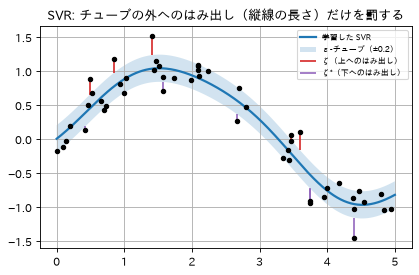

手計算 Σ (α_i − α_i*) K(x_i, x) + b と predict が一致: True
dual_coef_ = α_i − α_i* はすべて −C〜C の範囲: True
e^T (α − α*) = 0（dual_coef_ の合計）: True


In [19]:
rng = np.random.RandomState(1)
xr = np.sort(rng.uniform(0, 5, 50))[:, None]
yr_ = np.sin(xr[:, 0]) + 0.25 * rng.randn(50)
eps, C = 0.2, 10
svr = svm.SVR(kernel="rbf", gamma=0.5, C=C, epsilon=eps).fit(xr, yr_)
g = np.linspace(0, 5, 300)[:, None]; pred = svr.predict(g); pred_tr = svr.predict(xr)

plt.plot(g, pred, lw=2, label="学習した SVR")
plt.fill_between(g[:, 0], pred - eps, pred + eps, alpha=0.2, label=f"ε-チューブ（±{eps}）")
above = yr_ > pred_tr + eps; below = yr_ < pred_tr - eps
plt.vlines(xr[above, 0], pred_tr[above] + eps, yr_[above], colors="tab:red", label="ζ（上へのはみ出し）")
plt.vlines(xr[below, 0], yr_[below], pred_tr[below] - eps, colors="tab:purple", label="ζ*（下へのはみ出し）")
plt.scatter(xr, yr_, s=15, c="k", zorder=3)
plt.legend(fontsize=7); plt.title("SVR: チューブの外へのはみ出し（縦線の長さ）だけを罰する"); plt.show()

manual = rbf_kernel(xr, svr.support_vectors_, gamma=0.5) @ svr.dual_coef_[0] + svr.intercept_[0]
print("手計算 Σ (α_i − α_i*) K(x_i, x) + b と predict が一致:", np.allclose(manual, svr.predict(xr)))
print("dual_coef_ = α_i − α_i* はすべて −C〜C の範囲:", (np.abs(svr.dual_coef_) <= C + 1e-9).all())
print("e^T (α − α*) = 0（dual_coef_ の合計）:", np.isclose(svr.dual_coef_.sum(), 0))

👀 縦線の長さが、各サンプルのスラック変数 $\zeta_i$（赤、チューブより上）と $\zeta_i^*$（紫、チューブより下）です。チューブの中の点は縦線がなく（罰 0）、予測にも影響しません。手計算の予測が `predict` と一致し、双対係数が制約を満たしていることも確かめられました。

#### 📖 LinearSVR

主問題は、次のように同じ意味で書き直せます。

$$\min_{w, b} \frac{1}{2} w^T w + C \sum_{i=1}^{n} \max(0, |y_i - (w^T \phi(x_i) + b)| - \varepsilon)$$

ここでは ε-不感損失を使っています。つまり、$\varepsilon$ 未満の誤差は無視されます。これが `LinearSVR` が直接最適化する形です。

---
## 5. 実装の詳細（1.4.8 Implementation details）

### 📖 ガイドの解説

内部では、すべての計算に **libsvm** と **liblinear** を使っています。これらのライブラリは、C と Cython でラップされています。実装の説明やアルゴリズムの詳細は、それぞれの論文を参照してください。

| ライブラリ | 使うクラス | 得意なこと |
|---|---|---|
| libsvm（Chang & Lin） | `SVC`, `NuSVC`, `SVR`, `NuSVR`, `OneClassSVM` | カーネルを使った SVM（双対問題を SMO 法で解く） |
| liblinear（Fan ら, 2008） | `LinearSVC`, `LinearSVR`（と `LogisticRegression(solver="liblinear")`） | 大規模な線形モデル |

> 📚 **用語**
> - **Cython**: Python と C の中間のような言語。Python から C のライブラリを速く呼び出すために使われる。
> - **SMO（Sequential Minimal Optimization）**: 双対問題の変数を 2 つずつ選んで解析的に最適化していく方法（Platt, 1998）。libsvm の基本的な解き方。

🕰️ **歴史（参考情報）**: LIBSVM は 2000 年ごろから国立台湾大学の**張智中（Chih-Chung Chang）と林智仁（Chih-Jen Lin）**が開発・公開してきたライブラリで、多くの言語やツールに組み込まれ、SVM を実務で広く使えるようにしました。LIBLINEAR は同じグループが 2008 年に発表した、大規模な線形分類のためのライブラリです。

---
## 6. まとめ

### 実践のチェックリスト

| 項目 | やること |
|---|---|
| スケーリング | **必ず**。`make_pipeline(StandardScaler(), SVC())` |
| カーネル | まず `rbf`（既定）。線形で十分そうなら `LinearSVC` |
| `C` と `gamma` | `GridSearchCV` で、10 倍刻み（指数的）に探す。斜めの帯に注目 |
| データが大きい | 数万件を超えるなら `LinearSVC`、`SGDClassifier`、カーネル近似（6.7 節）を検討 |
| 不均衡なデータ | `class_weight="balanced"`、少数派の再現率で評価 |
| 確率が必要 | `CalibratedClassifierCV(SVC(), ensemble=False)`（`probability=True` は非推奨） |
| `LinearSVC` の切片 | データを標準化するか、`intercept_scaling` を大きく |
| ノイズが多い | `C` を小さく（正則化を強く） |

### 数式と属性の対応

| 数式 | SVC | SVR |
|---|---|---|
| 双対係数 | `dual_coef_` = $y_i \alpha_i$ | `dual_coef_` = $\alpha_i - \alpha_i^*$ |
| 制約 | $0 \le \alpha_i \le C$、$y^T \alpha = 0$ | $0 \le \alpha_i, \alpha_i^* \le C$、$e^T(\alpha - \alpha^*) = 0$ |
| サポートベクター | `support_vectors_`（$\alpha_i > 0$ の点） | `support_vectors_`（チューブの外・縁の点） |
| 切片 | `intercept_` = $b$ | `intercept_` = $b$ |
| 予測 | $\operatorname{sign}\left(\sum_{i \in SV} y_i \alpha_i K(x_i, x) + b\right)$ | $\sum_{i \in SV} (\alpha_i - \alpha_i^*) K(x_i, x) + b$ |

### 覚えておきたい 3 つのこと

1. **SVM は「マージン最大化（$\frac{1}{2} w^T w$）」と「はみ出しの罰（$C \sum \zeta_i$）」の釣り合い**。`C` は正則化の逆数のように働く。
2. **双対問題では、予測はサポートベクターだけの重み付き和になる**。だからカーネルが使え、予測が軽い。
3. **実践では、スケーリングと `C` / `gamma` の探索が最重要**。カーネル SVM は大きなデータに弱いので、線形で足りるなら `LinearSVC`。

### 🧩 ドメインモデルの視点

- `SVC` の `kernel` 引数は、文字列（`"rbf"`）、関数（`my_kernel`）、`"precomputed"`（グラム行列を直接受け取る）の 3 通りを受け付けます。`"precomputed"` では `fit` / `predict` に渡すものの**意味自体が変わる**（特徴の行列 → カーネル行列）ので、同じメソッドでも引数の契約が切り替わります。型のある言語では、別のクラスやオーバーロードに分けたくなる設計です。
- 独自のカーネルのとき、`fit` の引数の**コピーではなく参照**が保存される、という注意書きがありました。外から渡されたデータを内部で保持するとき、コピーするか参照するかは、性能と安全性のトレードオフです。TypeScript / Java でも、受け取った配列を防御的にコピーするかどうかは、同じ判断になります。
- `LinearSVC` は `dual='auto'` で、データの形からソルバを自動で選びます。利用者に選択を委ねるか、ライブラリが賢く選ぶかの設計判断で、便利な反面、「`C` を大きくすると遅くなる」といった振る舞いが、データの形によって現れたり消えたりする原因にもなっています。

### ✅ 確認クイズ

**Q1.** カーネル SVM の学習時間は、サンプル数が 10 倍になるとおよそ何倍になりますか。

<details><summary>答え</summary>

およそ 100 倍〜1000 倍（$O(n_{samples}^2)$〜$O(n_{samples}^3)$）。線形で十分なら、ほぼ線形にスケールする `LinearSVC` を使います。
</details>

**Q2.** RBF カーネルの SVM で、学習データの正解率は高いのにテストの正解率が低いとき、`C` と `gamma` をどう変えますか。

<details><summary>答え</summary>

過学習しているので、`C` を小さく（はみ出しを許す）、または `gamma` を小さく（影響範囲を広く、境界をなめらかに）します。両方の組み合わせを交差検証で探すのが基本です。
</details>

**Q3.** SVC の `dual_coef_` には何が入っていますか。絶対値の上限はいくつですか。

<details><summary>答え</summary>

$y_i \alpha_i$（符号付きの双対係数）。$0 \le \alpha_i \le C$ なので、絶対値の上限は `C` です。上限に張り付いた点はマージン誤差です。
</details>

**Q4.** `NuSVC(nu=0.2)` で学習したとき、サポートベクターの割合とマージン誤差の割合について、何が言えますか。

<details><summary>答え</summary>

マージン誤差の割合は 0.2 以下、サポートベクターの割合は 0.2 以上です。
</details>

**Q5.** 特徴が原点から遠いデータで `LinearSVC` の境界がずれてしまいました。どう対処しますか。

<details><summary>答え</summary>

`LinearSVC` は切片も正則化するためです。データを標準化する（平均 0 にする）か、`intercept_scaling` を大きくします。
</details>

---
**前のノート**: [1/2 分類と回帰](./04_svm_1_classification_regression.ipynb) ・ **次の節**: [1.5 確率的勾配降下法](./05_sgd.ipynb)